# Battery SOC and SOH ML Benchmark Walkthrough
This CPU-only walkthrough uses synthetic data generated locally.

In [1]:
from battery_ml.config import ExperimentConfig, SimulationConfig
from battery_ml.experiment import run_soc_experiment, run_soh_experiment
from battery_ml.simulation import simulate_battery_data
from battery_ml.splits import split_by_cell

config = ExperimentConfig(
    simulation=SimulationConfig(n_cells=4, cycles_per_cell=5, samples_per_cycle=24),
    models=("ridge", "narx", "coulomb_counting", "ekf"),
)
frame = simulate_battery_data(config.simulation)
frame.head()

,timestamp_s,cell_id,cycle_id,sample_id,profile,segment,current_a,voltage_v,temperature_c,soc,capacity_ah,soh,internal_resistance_ohm,elapsed_cycle_s,cycle_start_soc
0,0.0,cell_00,0,0,urban,charge,-0.137783,3.905757,25.127905,0.793578,2.82133,1.0,0.041256,0.0,0.793439
1,10.0,cell_00,0,1,urban,charge,-1.726140,3.967432,26.082848,0.795274,2.82133,1.0,0.041256,10.0,0.793439
2,20.0,cell_00,0,2,urban,charge,-1.010203,3.951168,25.381352,0.796274,2.82133,1.0,0.041256,20.0,0.793439
3,30.0,cell_00,0,3,urban,charge,-2.169840,3.986631,25.958453,0.798404,2.82133,1.0,0.041256,30.0,0.793439
4,40.0,cell_00,0,4,urban,charge,-1.940691,3.992157,26.557094,0.800320,2.82133,1.0,0.041256,40.0,0.793439


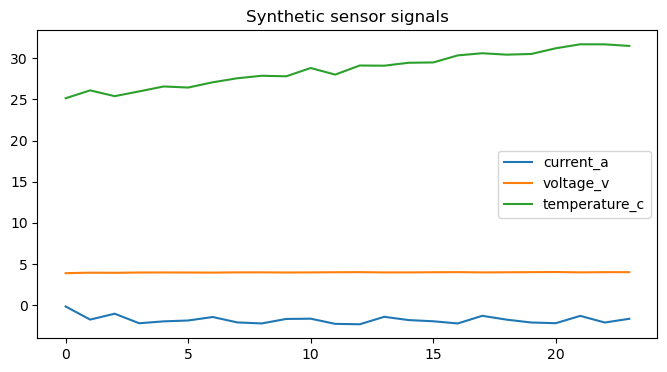

In [2]:
import matplotlib.pyplot as plt

cycle = frame.query("cell_id == 'cell_00' and cycle_id == 0")
plt.figure(figsize=(8, 4))
for column in ["current_a", "voltage_v", "temperature_c"]:
    plt.plot(cycle[column], label=column)
plt.title("Synthetic sensor signals")
plt.legend()
plt.show()

In [3]:
split = split_by_cell(frame, seed=42)
assert set(split.train.cell_id).isdisjoint(split.test.cell_id)
set(split.train.cell_id), set(split.test.cell_id)

({'cell_00', 'cell_01'}, {'cell_03'})

In [4]:
soc_metrics, _ = run_soc_experiment(config, frame)
soh_metrics, _ = run_soh_experiment(config, frame)
soc_metrics[["model", "rmse", "mae", "r2", "runtime_seconds"]]
soh_metrics[["model", "rmse", "mae", "r2"]]

,model,rmse,mae,r2
0,ridge,0.004555,0.003872,0.691597
